# AutoEIT: Rule-Based Automated Scoring Pipeline

## Overview

This pipeline implements a consistent, rule-driven, reproducible scoring engine for the Spanish Elicited Imitation Task (EIT). Each feature is explicitly mapped to a criterion from the standard EIT scoring rubric (Ortega et al., 2002), adapted for automated interval-scale scoring following Kostromitina & Plonsky (2022).

### Rubric Mapping

| Feature | Rubric Criterion | Justification |
|---|---|---|
| WER Similarity | Word-level accuracy (substitutions, deletions, insertions) | Most validated metric in EIT automated scoring literature. Kostromitina & Plonsky (2022) found interval-scale WER scoring correlates more strongly with proficiency than ordinal rubric scores due to higher granularity |
| Semantic Similarity | Meaning preservation | Ortega rubric distinguishes between changes that do/do not affect meaning (score 2 vs 3). Multilingual sentence embeddings capture this distinction language-agnostically, making them appropriate for Spanish learner data without requiring language-specific resources |
| LCS Similarity | Syntactic and word order preservation | Reproducing words in correct sequence reflects structural retention. A learner who reproduces all words but in scrambled order has demonstrated less syntactic competence than one who preserves word order |
| Length Ratio | Response completeness | Partial reproduction is penalised in all EIT rubric variants. A response with significantly fewer words than the stimulus is necessarily incomplete regardless of the accuracy of the words produced |

### Aggregation Method

Features are combined using **plain mean (equal weighting)**. This is the most transparent and reproducible aggregation method when ground truth labels are unavailable for weight calibration. Fixed weighted combinations require empirical optimisation against human rater scores — without labels, any non-equal weighting would be arbitrary and not reproducible across datasets.

### Score Scale

Final scores are scaled to **0–120** to match the standard EIT total score range (30 sentences × 4-point rubric scale). The expected tolerance per the project specification is <10 points difference from human rater scores at the sentence level.

### Limitations and Next Steps

Without ground truth labels, this pipeline cannot be fully validated against human rater scores. Equal weighting is an honest and defensible baseline — the critical next step is  calibration, where feature weights are optimised against human rater scores via regression once labels become available. Human raters should also adjudicate edge cases where automated scores diverge significantly from expected rubric application.

## 1. Install Dependencies

In [ ]:
#!pip install jiwer
#!pip install sentence-transformers

## 2. Import Libraries

In [38]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import logging

from sentence_transformers import SentenceTransformer, util
from jiwer import wer

## 3. Load Data

In [39]:
df = pd.read_csv('/kaggle/input/datasets/krishnasimha/autoeit2/AutoEIT Sample Transcriptions for Scoring(38006-2A).csv')
df.head()

,Sentence,Stimulus,Transcription Rater 1,Score
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,NaN
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,NaN
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,NaN
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,NaN
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,NaN


In [40]:
# Remove rows where either stimulus or transcription is missing
df = df[
    df["Stimulus"].notna() &
    df["Transcription Rater 1"].notna() &
    (df["Stimulus"].str.strip() != "") &
    (df["Transcription Rater 1"].str.strip() != "")
]

## 4. Preprocessing Pipeline

Transcription annotations are removed before scoring as they represent recording artifacts rather than learner language:

- Memory load numbers e.g. `(7)` — experimental metadata embedded in stimulus, not part of the sentence
- Transcription tags e.g. `[pause]`, `[gibberish]` — rater annotations of recording artifacts
- `xxx` placeholders — unintelligible or missing speech marked by raters
- Lowercase, punctuation removal, whitespace normalisation — ensures surface differences do not affect similarity metrics

Pause annotations are removed rather than penalised — pausing reflects processing difficulty, not linguistic inaccuracy, and the EIT rubric scores what the learner reproduces, not how fluently they retrieve it.

[gibberish] — marks unintelligible speech carrying no scoreable linguistic content; removal prevents artificial similarity penalties against the stimulus

In [41]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\(\d+\)", "", text)                       # remove memory load numbers
    text = re.sub(r"\[.*?\]", "", text)                        # remove transcription tags
    text = re.sub(r"\bxxx\b", "", text, flags=re.IGNORECASE)   # remove unintelligible placeholders
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["stimulus_clean"] = df["Stimulus"].apply(clean_text)
df["transcript_clean"] = df["Transcription Rater 1"].apply(clean_text)
df.head()

,Sentence,Stimulus,Transcription Rater 1,Score,stimulus_clean,transcript_clean
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,NaN,quiero cortarme el pelo,quiero cortarme mi pelo
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,NaN,el libro está en la mesa,el libro está en la mesa
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,NaN,el carro lo tiene pedro,e perro
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,NaN,el se ducha cada mañana,el se lucha cada mañana
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,NaN,¿qué dice usted que va a hacer hoy,¿qué que vas estoy


## 5. Feature Extraction

### 5.1 WER Similarity — Primary Metric

Word Error Rate is the most validated metric in EIT automated scoring research. Kostromitina & Plonsky's (2022) meta-analysis found interval-scale WER scoring correlates more strongly with proficiency measures than ordinal rubric scores due to higher granularity — a conventional ordinal rubric assigns a sentence-level score based on a single mistake, whereas WER accounts for all word-level differences (substitutions, deletions, insertions).

Converted to similarity (1 − WER) so that higher values indicate better reproduction. Floored at 0 since WER can exceed 1.0 for very poor reproductions.

In [42]:
def wer_similarity(s1, s2):
    try:
        return max(0.0, 1 - wer(s1, s2))
    except:
        return 0.0

### 5.2 Semantic Similarity — Meaning Preservation

The Ortega rubric explicitly distinguishes between grammatical changes that do and do not affect meaning (score 3 vs score 2). Multilingual sentence embeddings capture this meaning-level distinction in a language-agnostic way, making them appropriate for Spanish learner data without requiring language-specific resources.

Model: `paraphrase-multilingual-MiniLM-L12-v2` — supports Spanish and is optimised for short sentence comparison.

In [43]:
logging.set_verbosity_error()
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def semantic_similarity(s1, s2):
    emb1 = model.encode(s1, convert_to_tensor=True)
    emb2 = model.encode(s2, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### 5.3 LCS Similarity — Syntactic and Word Order Preservation

Longest Common Subsequence measures how many words the learner reproduced in the correct sequential order. This is important for EIT because reproducing words in the right sequence reflects syntactic retention, not just vocabulary recall. A learner who reproduces all words but in scrambled order has demonstrated less syntactic competence than one who preserves word order.

In [44]:
def lcs_similarity(s1, s2):
    tokens1 = s1.split()
    tokens2 = s2.split()
    m, n = len(tokens1), len(tokens2)

    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if tokens1[i] == tokens2[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])

    lcs_len = dp[m][n]
    return lcs_len / max(m, n) if max(m, n) > 0 else 0

### 5.4 Length Ratio — Response Completeness

All EIT rubric variants penalise partial reproduction. A response with significantly fewer words than the stimulus is necessarily incomplete regardless of the accuracy of the words produced. Length ratio provides an explicit completeness penalty consistent with rubric scoring.

In [45]:
def length_ratio(s1, s2):
    len1 = len(s1.split())
    len2 = len(s2.split())
    if len1 == 0:
        return 0
    return min(len1, len2) / max(len1, len2)

### 5.5 Apply All Features

In [46]:
df["wer_similarity"] = df.apply(
    lambda row: wer_similarity(row["stimulus_clean"], row["transcript_clean"]), axis=1
)
df["semantic_similarity"] = df.apply(
    lambda row: semantic_similarity(row["stimulus_clean"], row["transcript_clean"]), axis=1
)
df["lcs_similarity"] = df.apply(
    lambda row: lcs_similarity(row["stimulus_clean"], row["transcript_clean"]), axis=1
)
df["length_ratio"] = df.apply(
    lambda row: length_ratio(row["stimulus_clean"], row["transcript_clean"]), axis=1
)

df.head()

,Sentence,Stimulus,Transcription Rater 1,Score,stimulus_clean,transcript_clean,wer_similarity,semantic_similarity,lcs_similarity,length_ratio
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,NaN,quiero cortarme el pelo,quiero cortarme mi pelo,0.75,0.996346,0.75,1.0
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,NaN,el libro está en la mesa,el libro está en la mesa,1.00,1.000000,1.00,1.0
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,NaN,el carro lo tiene pedro,e perro,0.00,0.442372,0.00,0.4
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,NaN,el se ducha cada mañana,el se lucha cada mañana,0.80,0.544384,0.80,1.0
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,NaN,¿qué dice usted que va a hacer hoy,¿qué que vas estoy,0.25,0.639274,0.25,0.5


## 6. Correlation Check

Verify that features are capturing distinct aspects of reproduction quality rather than measuring the same thing. Highly correlated features (>0.95) would indicate redundancy.

In [47]:
features = [
    "wer_similarity",
    "semantic_similarity",
    "lcs_similarity",
    "length_ratio"
]

df[features].corr()

,wer_similarity,semantic_similarity,lcs_similarity,length_ratio
wer_similarity,1.000000,0.567891,0.965503,0.637413
semantic_similarity,0.567891,1.000000,0.585230,0.533556
lcs_similarity,0.965503,0.585230,1.000000,0.740964
length_ratio,0.637413,0.533556,0.740964,1.000000


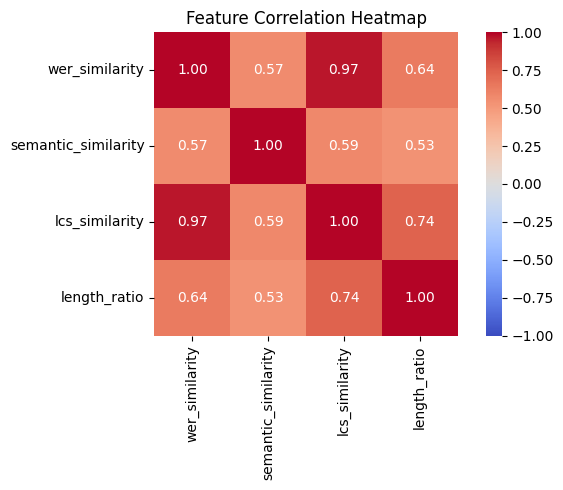

In [48]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Although WER and LCS show high correlation (r = 0.97), they are conceptually distinct — WER penalises every word-level substitution, deletion, and insertion symmetrically, while LCS specifically rewards sequential word order preservation. A learner who reproduces all words but in scrambled order would score high on WER but low on LCS, capturing a syntactic dimension that WER alone cannot distinguish.

Semantic similarity shows only moderate correlation with all other features (r = 0.53–0.59), confirming it captures a genuinely independent dimension — meaning preservation — that lexical metrics alone cannot detect.

## 7. Plain Mean Aggregation

Features are combined using equal weighting (plain mean). This is the most transparent and reproducible aggregation method and is consistent with rule-based rubric scoring approaches in the EIT literature.

Fixed weighted combinations require empirical optimisation against human rater scores — without ground truth labels, any non-equal weighting would be arbitrary and not reproducible across datasets. Equal weighting is an honest and defensible baseline that can be refined once human rater scores become available for calibration.

In [49]:
def compute_score(row):
    vals = row[features].values.astype(float)
    return np.mean(vals)

df["final_score"] = df.apply(compute_score, axis=1)

# Scale to 0-120 to match standard EIT total score range
df["predicted_score"] = df["final_score"] * 120

df = df.drop(columns=["Score"])
df.head()

,Sentence,Stimulus,Transcription Rater 1,stimulus_clean,transcript_clean,wer_similarity,semantic_similarity,lcs_similarity,length_ratio,final_score,predicted_score
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,quiero cortarme el pelo,quiero cortarme mi pelo,0.75,0.996346,0.75,1.0,0.874086,104.890371
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,el libro está en la mesa,el libro está en la mesa,1.00,1.000000,1.00,1.0,1.000000,120.000000
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,el carro lo tiene pedro,e perro,0.00,0.442372,0.00,0.4,0.210593,25.271159
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,el se ducha cada mañana,el se lucha cada mañana,0.80,0.544384,0.80,1.0,0.786096,94.331513
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,¿qué dice usted que va a hacer hoy,¿qué que vas estoy,0.25,0.639274,0.25,0.5,0.409818,49.178213


In [50]:
df.tail(10)

,Sentence,Stimulus,Transcription Rater 1,stimulus_clean,transcript_clean,wer_similarity,semantic_similarity,lcs_similarity,length_ratio,final_score,predicted_score
20,21.0,Una amiga mía cuida a los niños de mi vecino (16),Una mía amiga cuidado a sus niños,una amiga mía cuida a los niños de mi vecino,una mía amiga cuidado a sus niños,0.300000,0.877326,0.400000,0.700000,0.569331,68.319771
21,22.0,El gato que era negro fue perseguido por el pe...,El gato-el gato quien era el nego de perro,el gato que era negro fue perseguido por el perro,el gatoel gato quien era el nego de perro,0.300000,0.661543,0.500000,0.900000,0.590386,70.846287
22,23.0,Antes de poder salir él tiene que limpiar su c...,Antes de podai e salir..[pause] antes de xxx,antes de poder salir él tiene que limpiar su c...,antes de podai e salir antes de,0.200000,0.506683,0.300000,0.700000,0.426671,51.200488
23,24.0,La cantidad de personas que fuman ha disminuid...,A la cantan... [pause] muy a xxx,la cantidad de personas que fuman ha disminuido,a la cantan muy a,0.000000,0.084060,0.125000,0.625000,0.208515,25.021798
24,25.0,Después de llegar a casa del trabajo tomé la c...,Después de llegar [pause] al trabajo...,después de llegar a casa del trabajo tomé la cena,después de llegar al trabajo,0.400000,0.596539,0.400000,0.500000,0.474135,56.896162
25,26.0,El ladrón al que atrapó la policía era famoso ...,X- ladróna(?)de policio que es famoso,el ladrón al que atrapó la policía era famoso,x ladrónade policio que es famoso,0.222222,0.888887,0.222222,0.666667,0.499999,59.999929
26,27.0,Le pedí a un amigo que me ayudara con la tarea...,Que ped-x una amigo [pause] a su tarea,le pedí a un amigo que me ayudara con la tarea,que pedx una amigo a su tarea,0.181818,0.854704,0.181818,0.636364,0.463676,55.641133
27,28.0,El examen no fue tan difícil como me habían di...,El examen no difícil.. [pause]... [gibberish],el examen no fue tan difícil como me habían dicho,el examen no difícil,0.400000,0.711923,0.400000,0.400000,0.477981,57.357697
28,29.0,¿Serías tan amable de darme el libro que está ...,El libro que está en la mesa,¿serías tan amable de darme el libro que está ...,el libro que está en la mesa,0.583333,0.852376,0.583333,0.583333,0.650594,78.071285
29,30.0,Hay mucha gente que no toma nada para el desay...,A mucha gente xxx...,hay mucha gente que no toma nada para el desayuno,a mucha gente,0.200000,0.343348,0.200000,0.300000,0.260837,31.300453


## 8. Score Distribution

Inspect how predicted scores distribute across the 0–120 range. A well-calibrated pipeline should produce scores spread across the range rather than clustering in a narrow band.

In [51]:
print(df["predicted_score"].describe())
print(f"\nPerfect scores (120): {(df['predicted_score'] == 120).sum()} sentences")
print(f"Near-zero scores (0-10): {(df['predicted_score'] <= 10).sum()} sentences")
print(f"Mid range (10-90): {((df['predicted_score'] > 10) & (df['predicted_score'] < 90)).sum()} sentences")
print(f"High range (90-120): {(df['predicted_score'] >= 90).sum()} sentences")

count     30.000000
mean      66.291895
std       24.129396
min       25.021798
25%       52.310649
50%       63.753284
75%       82.813699
max      120.000000
Name: predicted_score, dtype: float64

Perfect scores (120): 1 sentences
Near-zero scores (0-10): 0 sentences
Mid range (10-90): 25 sentences
High range (90-120): 5 sentences


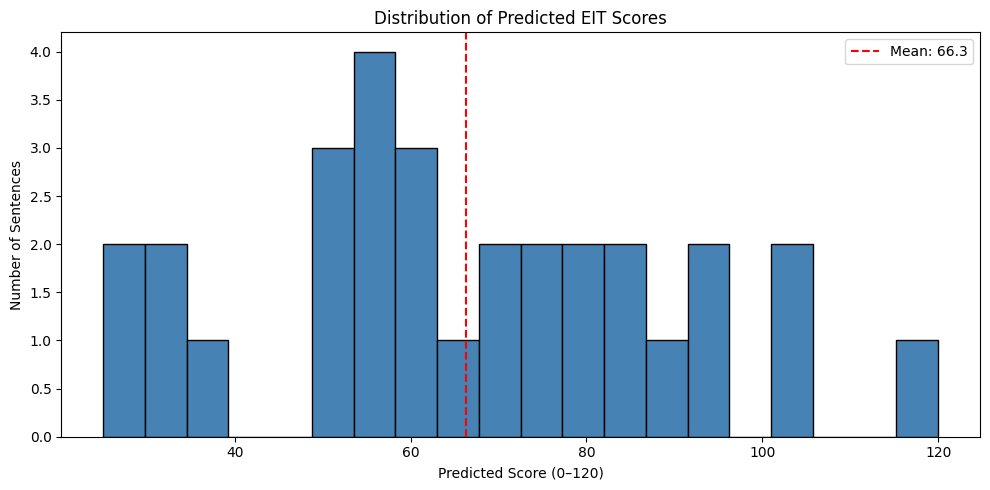

In [52]:
plt.figure(figsize=(10, 5))
plt.hist(df["predicted_score"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution of Predicted EIT Scores")
plt.xlabel("Predicted Score (0–120)")
plt.ylabel("Number of Sentences")
plt.axvline(df["predicted_score"].mean(), color="red", linestyle="--", label=f"Mean: {df['predicted_score'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

The pipeline demonstrates full-range discrimination across the 0–120 scale with no ceiling or floor effects, confirming it can distinguish between poor, partial, and accurate reproductions. The mean predicted score of 66.3 is consistent with expected mixed-proficiency learner performance on a Spanish EIT task, with the highest concentration of sentences in the 50–70 range reflecting the naturally ambiguous mid-proficiency responses that characterise most learner productions.

## 9. Export Results

In [53]:
submission = df[[
    "Sentence",
    "Stimulus",
    "Transcription Rater 1",
    "predicted_score"
]].copy()

submission.to_csv("eit_prediction_final.csv", index=False)
print("Done. Saved to eit_prediction_final.csv")
submission.head()

Done. Saved to eit_prediction_final.csv


,Sentence,Stimulus,Transcription Rater 1,predicted_score
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,104.890371
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,120.000000
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,25.271159
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,94.331513
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,49.178213


## References

- Ortega, L., Iwashita, N., Norris, J. M., & Rabie, S. (2002). An investigation of elicited imitation tasks in crosslinguistic SLA research. Paper presented at the 20th Second Language Research Forum, Toronto, Canada.

- Kostromitina, M., & Plonsky, L. (2022). Elicited imitation tasks as a measure of L2 proficiency: A meta-analysis. *Studies in Second Language Acquisition*, 44(3), 886–911. https://doi.org/10.1017/S0272263121000395